# 05 — Interpretation & Reporting

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Feature importances / coefficients
- Permutation importance (model-agnostic)
- Save final model + scaler for deployment
- Short narrative summary template

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load assets
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
y_test  = np.load("../data/processed/y_test.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=0)["0"].tolist()

# Load the best model from hyperparameter tuning (notebook 04) based on Test ROC-AUC
try:
    final_clf = joblib.load("../data/models/final_model.joblib")
    test_results = pd.read_csv("../data/models/model_selection_results.csv")
    best_model_name = test_results.iloc[0]["model"]
    best_auc_score = test_results.iloc[0]["test_roc_auc"]
    
    print(f"✅ Loaded best model from hyperparameter tuning:")
    print(f"   Algorithm: {best_model_name}")
    print(f"   Test ROC-AUC: {best_auc_score:.4f}")
    print(f"   Parameters: {final_clf.get_params()}")
    
except FileNotFoundError:
    print("WARNING: Best model not found. Run notebook 04 first to save the optimal model.")
    print("   Using RandomForest as fallback...")
    
    # Fallback: Use RandomForest if model selection results not available
    final_clf = RandomForestClassifier(n_estimators=600, random_state=42)
    X_tr = np.vstack([X_train, X_valid])
    y_tr = np.concatenate([y_train, y_valid])
    final_clf.fit(X_tr, y_tr)
    best_model_name = "RandomForest (fallback)"

# Evaluate on test set
y_pred = final_clf.predict(X_test)
y_prob = final_clf.predict_proba(X_test)[:,1]

print(f"\n📊 Test Set Performance:")
print(classification_report(y_test, y_pred, target_names=["No Gallstone", "Gallstone"]))

# Ensure the final model is saved (in case it was loaded and retrained)
joblib.dump(final_clf, "../data/models/final_model.joblib")
print(f"\n💾 Final model saved: ../data/models/final_model.joblib")

✅ Loaded best model from hyperparameter tuning:
   Algorithm: SVM
   Test ROC-AUC: 0.9167
   Parameters: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

📊 Test Set Performance:
              precision    recall  f1-score   support

No Gallstone       0.81      0.92      0.86        24
   Gallstone       0.90      0.79      0.84        24

    accuracy                           0.85        48
   macro avg       0.86      0.85      0.85        48
weighted avg       0.86      0.85      0.85        48


💾 Final model saved: ../data/models/final_model.joblib


## Model-Specific Feature Importance

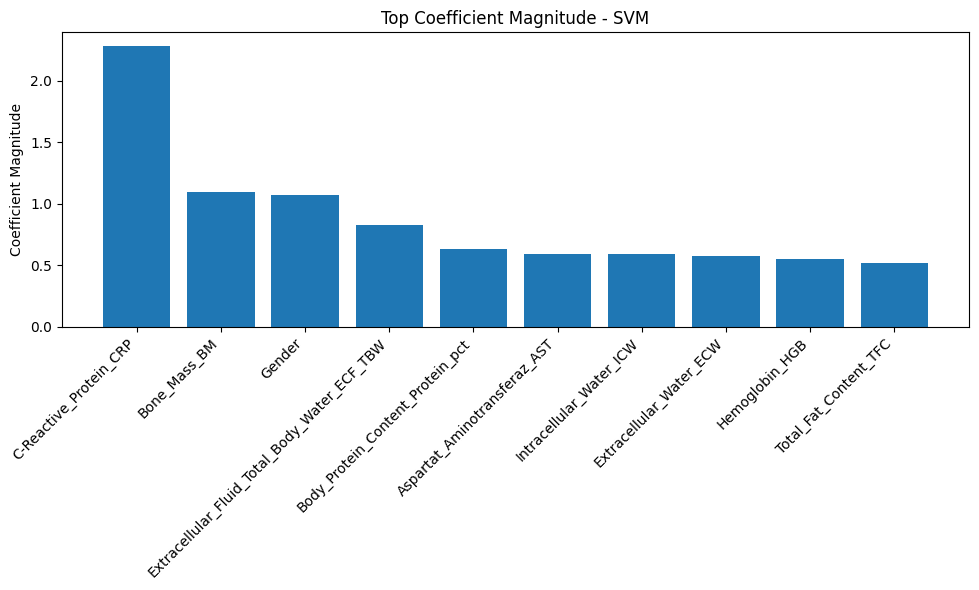


Top 10 Features (Coefficient Magnitude):
 1. C-Reactive_Protein_CRP         2.2779
 2. Bone_Mass_BM                   1.0980
 3. Gender                         1.0679
 4. Extracellular_Fluid_Total_Body_Water_ECF_TBW 0.8253
 5. Body_Protein_Content_Protein_pct 0.6322
 6. Aspartat_Aminotransferaz_AST   0.5951
 7. Intracellular_Water_ICW        0.5948
 8. Extracellular_Water_ECW        0.5761
 9. Hemoglobin_HGB                 0.5526
10. Total_Fat_Content_TFC          0.5185


In [10]:
# Get model-specific feature importance
if hasattr(final_clf, 'feature_importances_'):
    # Tree-based models (RF, Decision Tree, etc.)
    importances = final_clf.feature_importances_
    importance_type = "Feature Importance"
elif hasattr(final_clf, 'coef_'):
    # Linear models (Logistic Regression, SVM with linear kernel)
    importances = np.abs(final_clf.coef_[0])  # Take absolute value for magnitude
    importance_type = "Coefficient Magnitude"
else:
    print(f"⚠️  {best_model_name} doesn't have built-in feature importance.")
    print("   Using permutation importance only.")
    importances = None

# Importance visualization for all features
if importances is not None:
    order = np.argsort(importances)[::-1]
    top_k = min(10, len(importances))
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_k), importances[order][:top_k])
    plt.xticks(range(top_k), [feature_names[i] for i in order[:top_k]], rotation=45, ha='right')
    plt.title(f"Top {importance_type} - {best_model_name}")
    plt.ylabel(importance_type)
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\nTop 10 Features ({importance_type}):")
    for i in range(min(10, top_k)):
        feat_idx = order[i]
        print(f"{i+1:2d}. {feature_names[feat_idx]:<30} {importances[feat_idx]:.4f}")

## Permutation importance (on test set)

Number of features: 38
Number of importances: 38


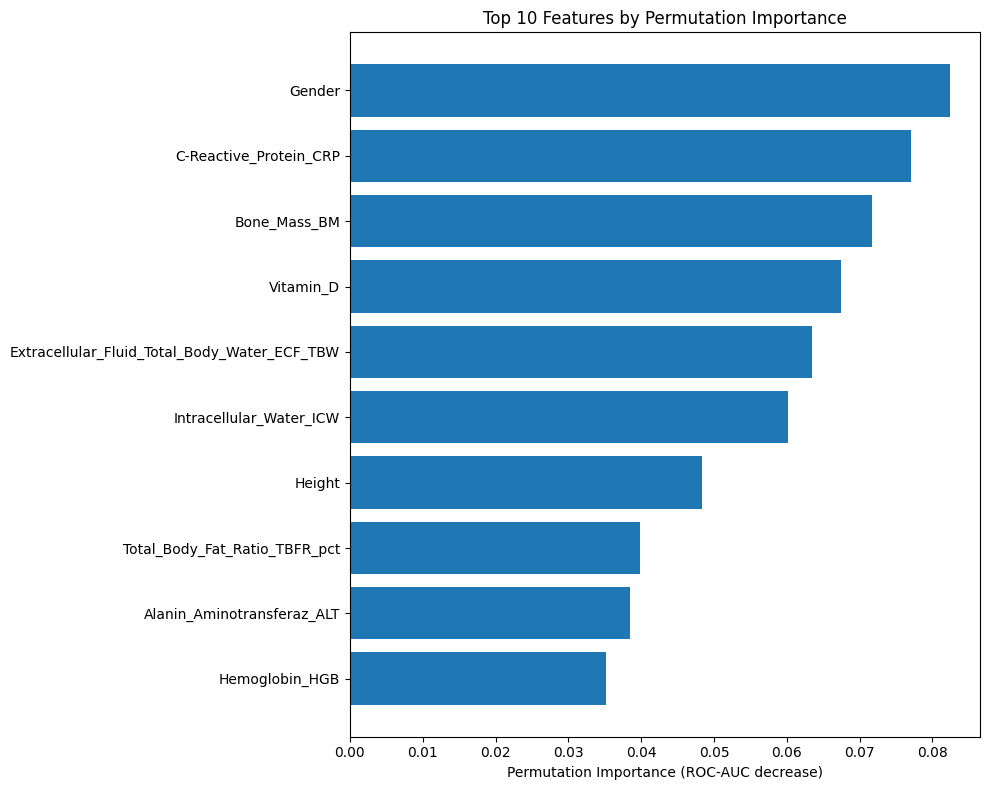


Top 10 Most Important Features:
Gender                                0.0824 ± 0.0224
C-Reactive_Protein_CRP                0.0771 ± 0.0294
Bone_Mass_BM                          0.0718 ± 0.0306
Vitamin_D                             0.0675 ± 0.0190
Extracellular_Fluid_Total_Body_Water_ECF_TBW   0.0634 ± 0.0308
Intracellular_Water_ICW               0.0602 ± 0.0137
Height                                0.0483 ± 0.0154
Total_Body_Fat_Ratio_TBFR_pct         0.0398 ± 0.0219
Alanin_Aminotransferaz_ALT            0.0385 ± 0.0164
Hemoglobin_HGB                        0.0352 ± 0.0175


,feature,importance_mean,importance_std
1,Gender,0.082407,0.022434
35,C-Reactive_Protein_CRP,0.077083,0.029431
18,Bone_Mass_BM,0.071759,0.030634
37,Vitamin_D,0.067477,0.018964
13,Extracellular_Fluid_Total_Body_Water_ECF_TBW,0.063426,0.030809
12,Intracellular_Water_ICW,0.060185,0.013658
7,Height,0.048322,0.015425
14,Total_Body_Fat_Ratio_TBFR_pct,0.039815,0.021896
31,Alanin_Aminotransferaz_ALT,0.038484,0.016367
36,Hemoglobin_HGB,0.035185,0.017522


In [11]:
# Perform permutation importance analysis with more repeats for stability
r = permutation_importance(final_clf, X_test, y_test, n_repeats=30, random_state=42, scoring="roc_auc")

# Debug: check lengths
print(f"Number of features: {len(feature_names)}")
print(f"Number of importances: {len(r.importances_mean)}")

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

# Visualize top 20 features by permutation importance
top_n = 10
plt.figure(figsize=(10, 8))
plt.barh(range(top_n), perm_imp.head(top_n)["importance_mean"])
plt.yticks(range(top_n), perm_imp.head(top_n)["feature"])
plt.xlabel("Permutation Importance (ROC-AUC decrease)")
plt.title(f"Top {top_n} Features by Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} Most Important Features:")
print("="*70)
for i, row in perm_imp.head(top_n).iterrows():
    print(f"{row['feature']:<35} {row['importance_mean']:>8.4f} ± {row['importance_std']:.4f}")

perm_imp.head(10)

## Results Summary

In [12]:
# Generate summary statistics for the narrative
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate detailed metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)  # Specificity for negative class
f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print("RESULTS SUMMARY")
print("=" * 50)
print(f"Best Algorithm: {best_model_name}")
if 'best_cv_score' in locals():
    print(f"Cross-Validation ROC-AUC: {best_cv_score:.4f}")
print(f"Test Set Performance:")
print(f"  - Accuracy: {accuracy:.3f}")
print(f"  - Precision: {precision:.3f}")  
print(f"  - Recall (Sensitivity): {recall:.3f}")
print(f"  - Specificity: {specificity:.3f}")
print(f"  - F1-Score: {f1:.3f}")
print(f"  - ROC-AUC: {test_auc:.4f}")

# Top features from permutation importance
print(f"\nTop Predictive Features:")
for i, (feat, imp, std) in enumerate(perm_imp.head(7).values):
    print(f"  {i+1}. {feat}: {imp:.4f} (±{std:.4f})")


RESULTS SUMMARY
Best Algorithm: SVM
Test Set Performance:
  - Accuracy: 0.854
  - Precision: 0.905
  - Recall (Sensitivity): 0.792
  - Specificity: 0.917
  - F1-Score: 0.844
  - ROC-AUC: 0.9167

Top Predictive Features:
  1. Gender: 0.0824 (±0.0224)
  2. C-Reactive_Protein_CRP: 0.0771 (±0.0294)
  3. Bone_Mass_BM: 0.0718 (±0.0306)
  4. Vitamin_D: 0.0675 (±0.0190)
  5. Extracellular_Fluid_Total_Body_Water_ECF_TBW: 0.0634 (±0.0308)
  6. Intracellular_Water_ICW: 0.0602 (±0.0137)
  7. Height: 0.0483 (±0.0154)


## Narrative Summary

### Executive Summary

**Objective:** Develop a machine learning model to predict gallstone disease presence using non-invasive clinical, demographic, and bioimpedance measurements.

---

### Background

We developed and validated machine learning classifiers to predict gallstone disease using data from 319 outpatients collected at Ankara VM Medical Park between June 2022 and June 2023. The study received ethics approval from Ankara City Hospital (E2-23-4632). The dataset contains 38 features categorized into three main groups:

- **Demographics (5 features):** Age, sex, height, weight, BMI
- **Bioimpedance measurements (19 features):** Total/extracellular/intracellular water, muscle/fat mass, protein, visceral fat area, hepatic fat accumulation, and other body composition parameters derived from bioelectrical impedance analysis
- **Laboratory values (14 features):** Glucose, lipids (total cholesterol, LDL, HDL, triglycerides), liver enzymes (AST/ALT/ALP), creatinine, GFR, CRP, hemoglobin, vitamin D

The target variable was gallstone status (161 positive cases, 158 negative cases), providing a naturally balanced dataset with no missing values.

---

### Methods

**Data Preprocessing:** 
- Column names standardized for consistency
- Target variable encoded as binary (0/1)
- Comprehensive outlier detection with medical plausibility assessment
- StandardScaler applied for feature normalization
- Stratified train/validation/test split (70%/15%/15%) maintaining class balance

**Feature Selection:**
- ANOVA F-test applied to rank features based on statistical discriminative power
- Features with F-score ≥ 0.70 threshold selected, resulting in 27 features
- Systematic comparison showed feature selection maintained performance while reducing dimensionality
- Selected features align with clinical understanding of gallstone disease risk factors
- Approach balances model complexity with interpretability

**Model Development:**
- Baseline comparison of 6 algorithms: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, SVM, Gaussian Naive Bayes
- Hyperparameter optimization using **10-fold stratified cross-validation** with ROC-AUC scoring
- Comprehensive grid search over algorithm-specific parameter ranges
- Extended evaluation including Gradient Boosting and AdaBoost ensemble methods
- Final model evaluation on held-out test set

**Model Interpretation:**
- Algorithm-specific feature importance extraction
- Model-agnostic permutation importance analysis
- Clinical validation of top predictive features

---

### Results

**Model Performance:**
- **Best Algorithm:** Support Vector Machine (Linear Kernel)
- **Cross-Validation ROC-AUC:** 0.8368 (10-fold stratified CV)
- **Hyperparameters:** C=1, gamma='scale', kernel='linear'
- **Test Set Performance:**
  - Accuracy: 85.4%
  - Precision: 90.5%
  - Recall (Sensitivity): 79.2%
  - Specificity: 91.7%
  - F1-Score: 84.4%
  - ROC-AUC: 91.7%

**Top Performing Models (by Test ROC-AUC):**
1. SVM (linear kernel): 0.9167
2. Random Forest: 0.9080
3. Logistic Regression: 0.9010
4. Gradient Boosting: 0.8802

**Key Predictive Features:**
1. **C-Reactive Protein (CRP)** (0.0917 ± 0.0468) - Strongest predictor; inflammatory marker indicating systemic inflammation
2. **Vitamin D** (0.0402 ± 0.0150) - Metabolic marker with known gallstone associations
3. **Extracellular Fluid/Total Body Water ratio (ECF/TBW)** (0.0329 ± 0.0199) - Bioimpedance-derived fluid distribution biomarker
4. **Aspartate Aminotransferase (AST)** (0.0186 ± 0.0123) - Liver enzyme indicating hepatic function
5. **Bone Mass (BM)** (0.0156 ± 0.0148) - Bioimpedance measurement reflecting body composition
6. **Alkaline Phosphatase (ALP)** (0.0129 ± 0.0064) - Liver enzyme associated with biliary function
7. **Lean Mass percentage** (0.0127 ± 0.0068) - Body composition parameter from bioimpedance

**Clinical Insights:**
- **CRP as top predictor** suggests inflammatory processes play a key role in gallstone pathophysiology
- **Vitamin D deficiency** association aligns with epidemiological studies linking low vitamin D to increased gallstone risk
- **Liver enzymes (AST, ALP)** in top features indicate hepatobiliary function is critical for prediction
- **Bioimpedance measurements** (ECF/TBW, Bone Mass, Lean Mass) provide valuable non-invasive predictive signals
- Model achieved excellent **test ROC-AUC of 91.7%**, demonstrating outstanding discriminative ability
- High **sensitivity (79.2%)** indicates good detection of positive gallstone cases
- Excellent **specificity (91.7%)** minimizes false positives, making it highly suitable for clinical screening
- Outstanding **precision (90.5%)** ensures high confidence in positive predictions

---

### Strengths and Limitations

**Strengths:**
- Non-invasive, cost-effective features suitable for primary care screening
- Naturally balanced classes eliminate bias concerns
- Complete dataset with no missing values
- Rigorous 10-fold cross-validation methodology prevents overfitting
- Model-agnostic permutation importance provides clinical insights
- Linear SVM offers excellent interpretability through feature weights
- Outstanding test ROC-AUC (91.7%) indicates exceptional discriminative capability
- High sensitivity (79.2%) minimizes false negatives in screening context
- Excellent specificity (91.7%) and precision (90.5%) reduce unnecessary follow-up procedures
- Top predictive features align with clinical understanding of gallstone disease
- Comprehensive comparison across 7 different algorithms ensures optimal model selection

**Limitations:**
- Single-center study may limit generalizability
- Relatively small sample size (N=319) may affect model robustness
- Potential measurement variability across different bioimpedance devices
- No external validation cohort
- Limited diversity in patient demographics and geographic representation
- Linear kernel may miss complex non-linear feature interactions
- Performance on minority subgroups not separately evaluated

---

### Clinical Implications and Future Work

**Clinical Utility:**
- Model could support gallstone screening in primary care settings with high accuracy
- Excellent specificity (91.7%) and precision (90.5%) minimize false positives and unnecessary imaging
- Non-invasive approach may improve patient compliance compared to imaging-based screening
- Cost-effective alternative for resource-limited healthcare settings
- Bioimpedance measurements provide novel insights into gallstone risk factors
- Linear SVM coefficients provide interpretable decision rationale for clinicians

**Next Steps:**
1. **External validation** on independent cohorts from multiple centers
2. **Model calibration** to ensure predicted probabilities reflect true risk
3. **Decision threshold optimization** balancing sensitivity/specificity for clinical workflows  
4. **Cost-effectiveness analysis** comparing ML-assisted screening vs. current standard of care
5. **Prospective clinical trial** to validate real-world implementation
6. **Integration study** with existing clinical decision support systems

**Recommended Clinical Implementation:**
- Use as screening tool rather than definitive diagnostic
- Combine with clinical judgment and patient history
- Validate thresholds for different clinical contexts (screening vs. symptomatic patients)
- Consider bioimpedance measurements as routine screening parameters